# DS Final Project Notebook

Use the follow cells prompts to complete the final project for the course. Everything you need should be present in this notebook or previous notebooks we've used in class. You can work together as needed.

- You will need to name your own dataset and use that name throughout
- There are sections where you need to make changes the code and insert new code this will be noted in the code provided
- You may get frustrated along the way, this is totally normal, just remember even small changes to the code make a huge difference.

### Question Fork the Repository
i. Include a screenshot of the forked repo in your GitHub account

To fork the repository:

1. Go to https://github.com/NovaVolunteer/ds1001_final
2. Click the "Fork" button in the top right corner
3. The repo will be forked to your GitHub account
4. Take a screenshot of your forked repository

### You should now be able to open your cloned repo in google collab, use the code below.
### It's very helpful to have the variable inspector open while you go through this process. To do so go to tools>command palette>show variable inspector
### It's also helpful to open up the folder tree on the left menu bar. Just click on the folder icon and then the ds1001_final folder. The data is located in the data folder in the processed sub-folder.

### Systems

### Check !pip list again to confirm installations

In [1]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import requests
import seaborn as sns
import sklearn

print(f"Scikit-Learn installed version: {sklearn.__version__}")

try:
    latest_sklearn = requests.get("https://pypi.org/pypi/scikit-learn/json", timeout=10).json()["info"]["version"]
    print(f"Scikit-Learn latest on PyPI: {latest_sklearn}")
    print(f"Is installed version latest? {sklearn.__version__ == latest_sklearn}")
except Exception as exc:
    print(f"Could not verify latest version online: {exc}")

ram_gb = psutil.virtual_memory().total / (1024**3)
disk_root = Path.cwd().anchor or str(Path.cwd())
disk_usage = shutil.disk_usage(disk_root)
disk_total_gb = disk_usage.total / (1024**3)
disk_free_gb = disk_usage.free / (1024**3)

print(f"Total RAM (GB): {ram_gb:.2f}")
print(f"Disk total on {disk_root} (GB): {disk_total_gb:.2f}")
print(f"Disk free on {disk_root} (GB): {disk_free_gb:.2f}")


def find_data_file(filename: str = "bank_final.csv") -> Path | None:
    candidate_paths = [
        Path(filename),
        Path("data/processed") / filename,
        Path("../data/processed") / filename,
        Path("/content") / filename,
        Path("/content/drive/MyDrive") / filename,
        Path("/content/drive/MyDrive/ds1001_final/data/processed") / filename,
    ]

    for candidate in candidate_paths:
        if candidate.exists():
            return candidate

    search_roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive")]
    for root in search_roots:
        if root.exists():
            for match in root.rglob(filename):
                return match

    return None


data_path = find_data_file("bank_final.csv")
if data_path is None:
    raise FileNotFoundError(
        "Could not find bank_final.csv. In Colab, upload the file to the session, place it in /content or data/processed/, or mount Google Drive and store it under /content/drive/MyDrive/."
    )

Scikit-Learn installed version: 1.8.0
Scikit-Learn latest on PyPI: 1.8.0
Is installed version latest? True
Total RAM (GB): 13.95
Disk total on c:\ (GB): 475.55
Disk free on c:\ (GB): 218.08


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

if "df" not in globals():
    def find_data_file(filename: str = "bank_final.csv") -> Path | None:
        candidate_paths = [
            Path(filename),
            Path("data/processed") / filename,
            Path("../data/processed") / filename,
            Path("/content") / filename,
            Path("/content/drive/MyDrive") / filename,
            Path("/content/drive/MyDrive/ds1001_final/data/processed") / filename,
        ]

        for candidate in candidate_paths:
            if candidate.exists():
                return candidate

        search_roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive")]
        for root in search_roots:
            if root.exists():
                for match in root.rglob(filename):
                    return match

        return None

    data_path = find_data_file("bank_final.csv")
    if data_path is None:
        raise FileNotFoundError(
            "Could not find bank_final.csv. In Colab, upload the file to the session, place it in /content or data/processed/, or mount Google Drive and store it under /content/drive/MyDrive/."
        )

    df = pd.read_csv(data_path)
    col_lookup = {c.lower(): c for c in df.columns}
    target_col = col_lookup.get("signed up")
    if target_col is None:
        raise KeyError("Target column 'signed up' was not found in the dataset.")

    print(f"Loaded dataset from: {data_path.resolve()}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"Numeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")

    print("\nMissing Data Count per Column:")
    print(df.isnull().sum())

    display(df.head())
else:
    loaded_path = globals().get("data_path")
    if loaded_path is not None:
        print(f"Dataset already loaded from: {loaded_path.resolve()}")


Loaded dataset from: C:\Users\Ethan\Downloads\DS 1001\ds1001_final\data\processed\bank_final.csv
Rows: 43628
Columns: 13
Numeric columns: 5
Categorical columns: 8

Missing Data Count per Column:
age             0
job             0
marital         0
education       0
race            0
default         0
balance         0
housing         0
contact         0
duration        0
contactndays    0
signed up       0
gender          0
dtype: int64


,age,job,marital,education,race,default,balance,housing,contact,duration,contactndays,signed up,gender
0,43,self-employed,married,tertiary,white,no,64,no,unknown,230,-1,0,m
1,74,retired,married,primary,white,no,5539,no,cellular,253,181,0,m
2,33,management,married,tertiary,hispanic,no,373,no,cellular,384,-1,0,m
3,37,blue-collar,married,secondary,asian,no,934,no,unknown,258,-1,0,m
4,30,technician,married,tertiary,white,no,1,no,cellular,69,-1,0,f


### Design: Data prep and exploration

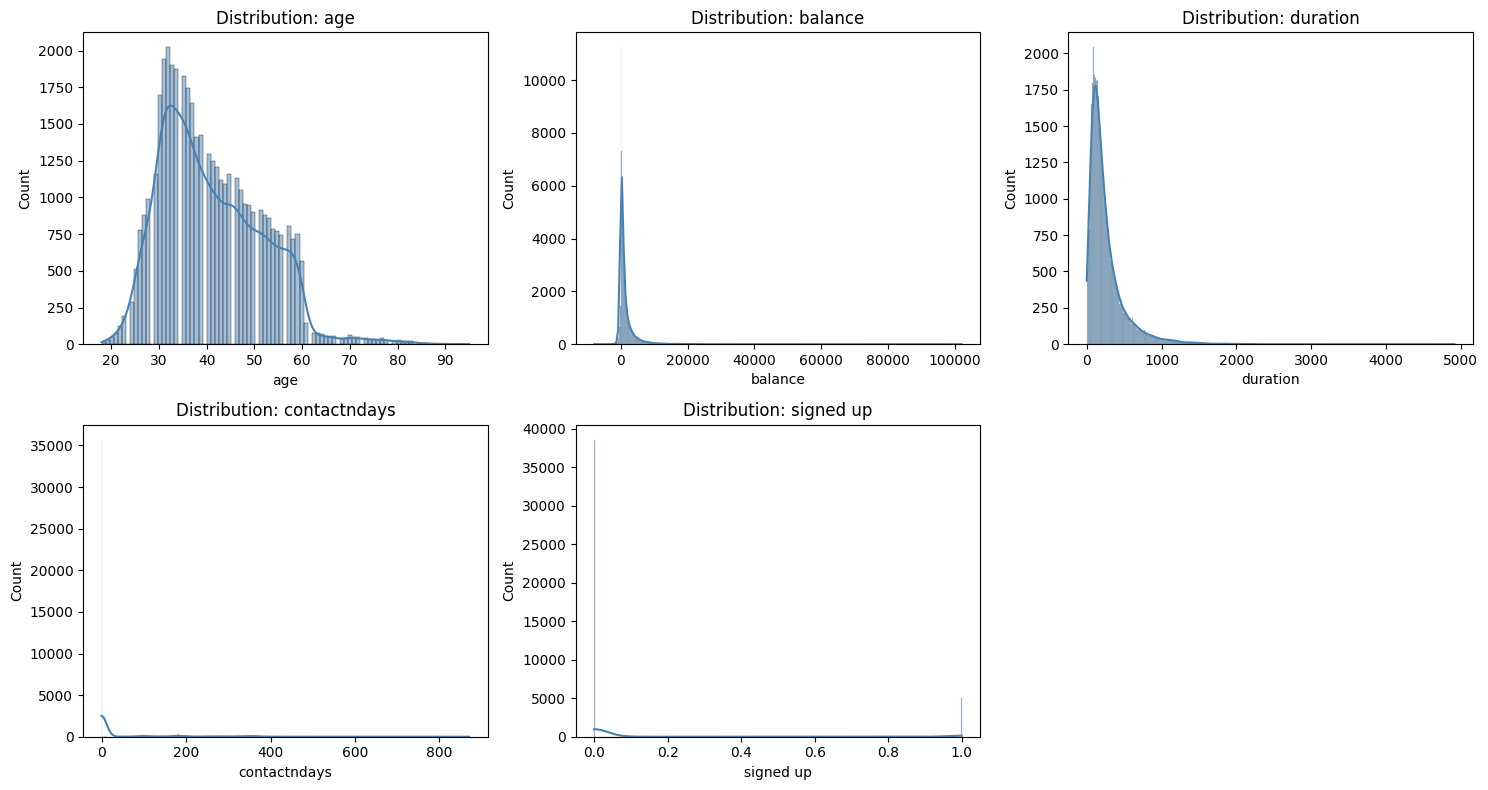

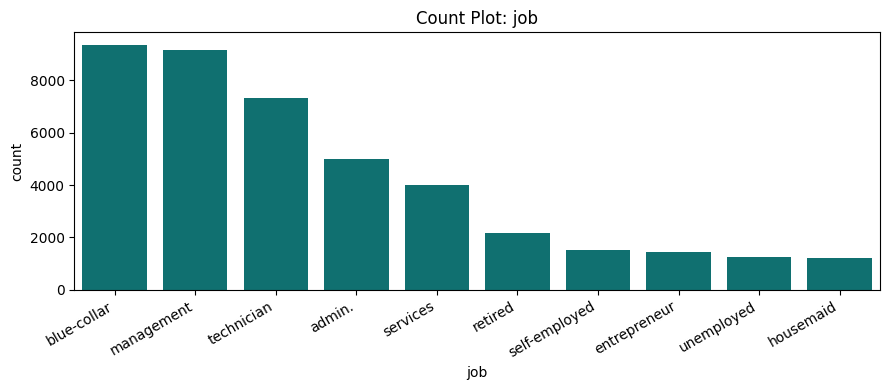

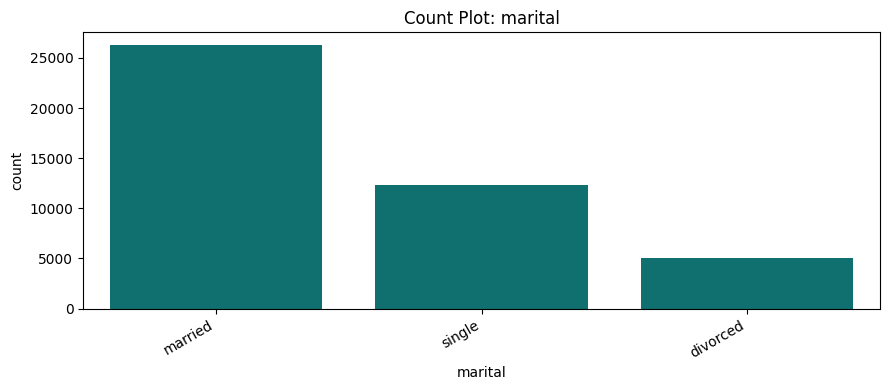

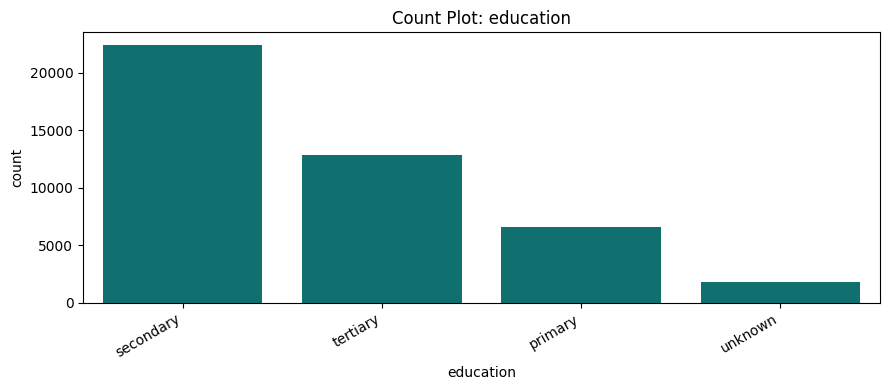

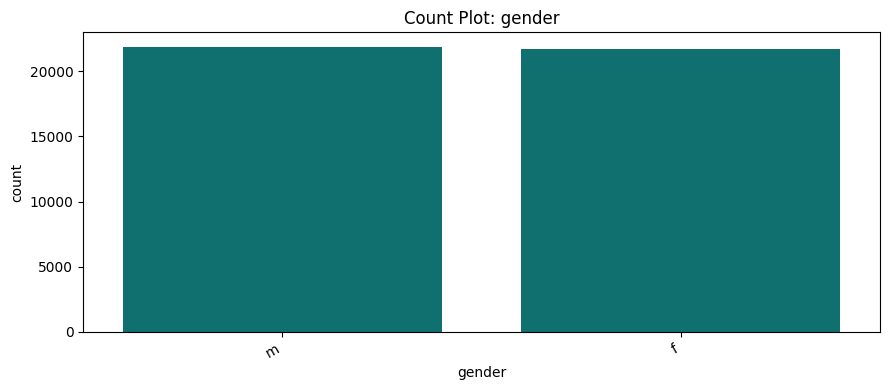

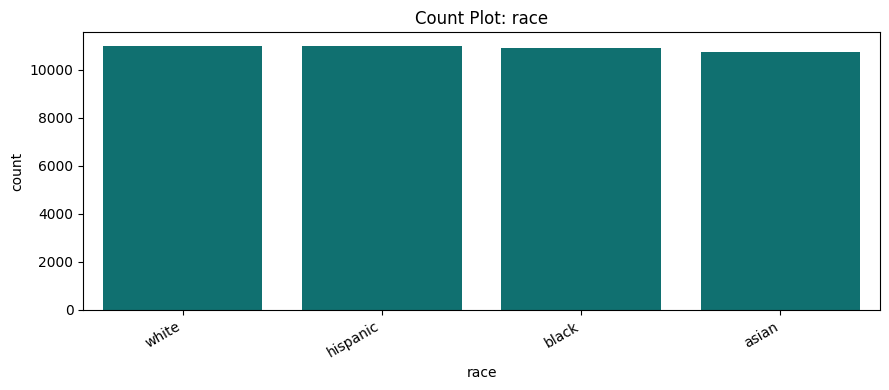

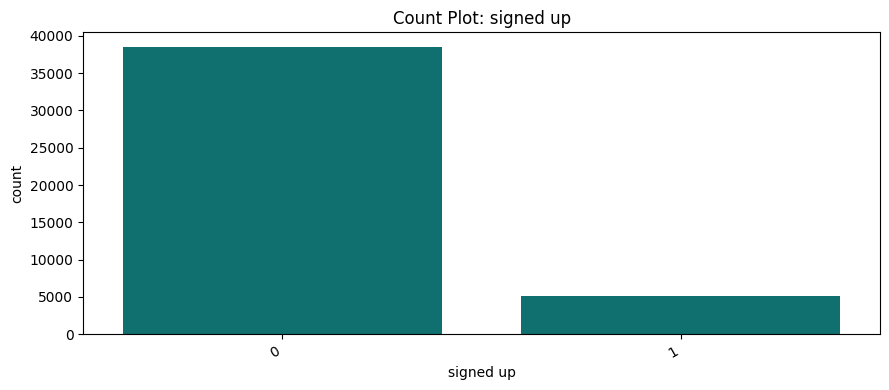

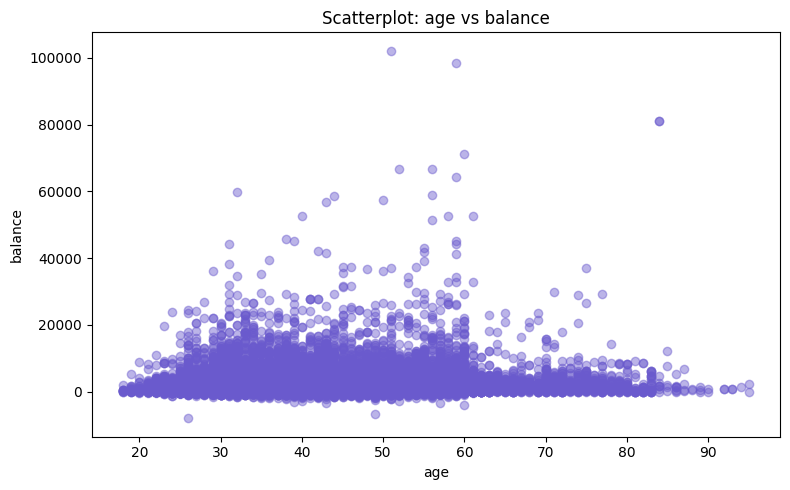

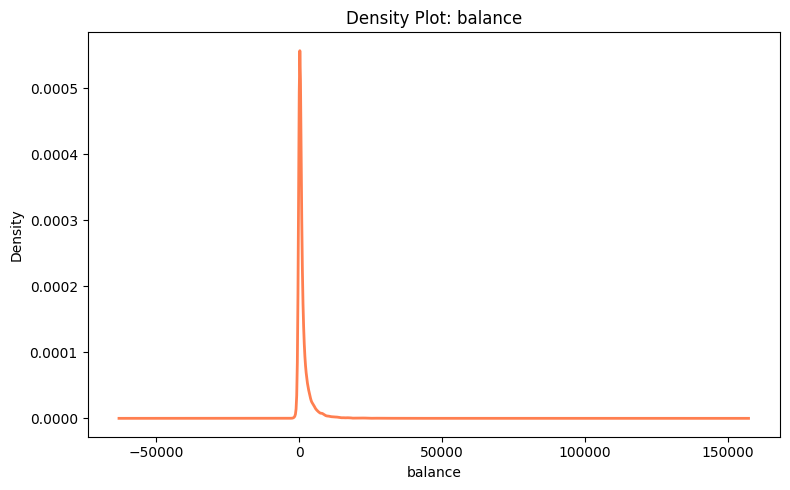

In [3]:
# Numeric feature histograms
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_numeric = len(numeric_cols)
n_cols = 3
n_rows = int(np.ceil(n_numeric / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution: {col}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

# Categorical feature count plots (top categories)
plot_candidates = ["job", "marital", "education", "gender", "race", "signed up"]
plot_cols = [col_lookup[c] for c in plot_candidates if c in col_lookup]
for col in plot_cols:
    plt.figure(figsize=(9, 4))
    order = df[col].astype(str).value_counts().index[:10]
    sns.countplot(data=df, x=col, order=order, color="teal")
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Required scatterplot between two continuous variables
age_col = col_lookup.get("age")
balance_col = col_lookup.get("balance")
if age_col and balance_col:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[age_col], df[balance_col], alpha=0.45, color="slateblue")
    plt.title(f"Scatterplot: {age_col} vs {balance_col}")
    plt.xlabel(age_col)
    plt.ylabel(balance_col)
    plt.tight_layout()
    plt.show()

# Required density chart of a continuous variable
if balance_col:
    plt.figure(figsize=(8, 5))
    df[balance_col].plot(kind="density", linewidth=2, color="coral")
    plt.title(f"Density Plot: {balance_col}")
    plt.xlabel(balance_col)
    plt.tight_layout()
    plt.show()

In [4]:
df = pd.read_csv(data_path)
col_lookup = {c.lower(): c for c in df.columns}
target_col = col_lookup.get("signed up")
if target_col is None:
    raise KeyError("Target column 'signed up' was not found in the dataset.")

print(f"Loaded dataset from: {data_path.resolve()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

print("\nMissing Data Count per Column:")
print(df.isnull().sum())

display(df.head())

Loaded dataset from: C:\Users\Ethan\Downloads\DS 1001\ds1001_final\data\processed\bank_final.csv
Rows: 43628
Columns: 13
Numeric columns: 5
Categorical columns: 8

Missing Data Count per Column:
age             0
job             0
marital         0
education       0
race            0
default         0
balance         0
housing         0
contact         0
duration        0
contactndays    0
signed up       0
gender          0
dtype: int64


,age,job,marital,education,race,default,balance,housing,contact,duration,contactndays,signed up,gender
0,43,self-employed,married,tertiary,white,no,64,no,unknown,230,-1,0,m
1,74,retired,married,primary,white,no,5539,no,cellular,253,181,0,m
2,33,management,married,tertiary,hispanic,no,373,no,cellular,384,-1,0,m
3,37,blue-collar,married,secondary,asian,no,934,no,unknown,258,-1,0,m
4,30,technician,married,tertiary,white,no,1,no,cellular,69,-1,0,f


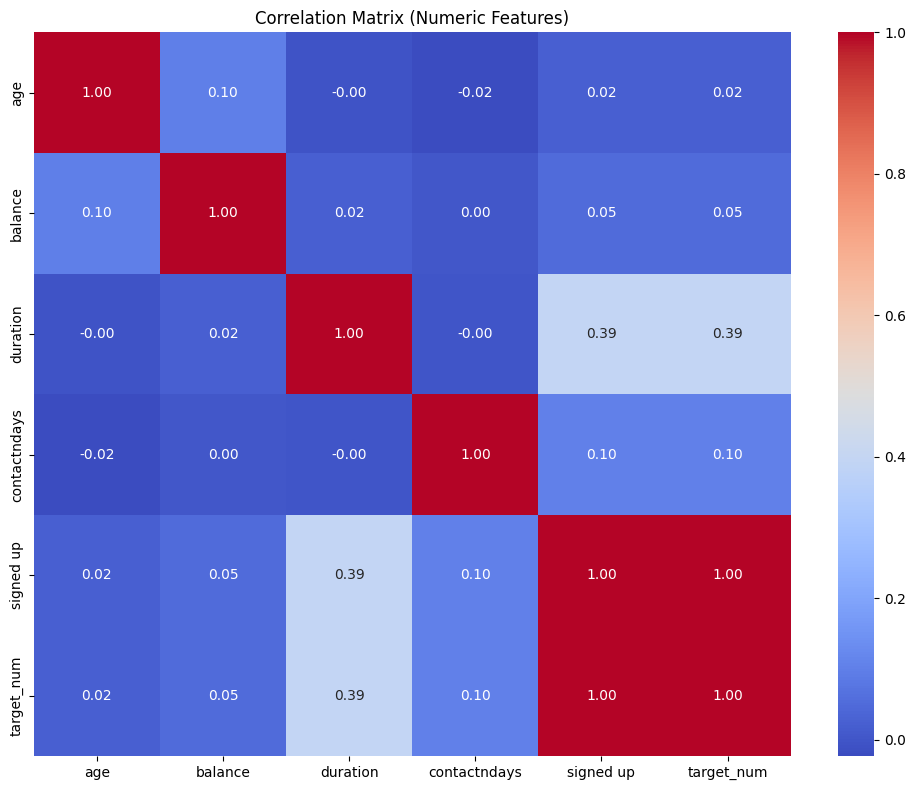

Correlations with target_num:
signed up       1.000000
target_num      1.000000
duration        0.394353
contactndays    0.101576
balance         0.051850
age             0.023936
Name: target_num, dtype: float64


In [5]:
# Correlation matrix using numeric features
corr_df = df.select_dtypes(include=[np.number]).copy()

if target_col and df[target_col].dtype == "object":
    corr_df["target_num"] = df[target_col].str.lower().map({"yes": 1, "no": 0})
elif target_col:
    corr_df["target_num"] = df[target_col]

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

if "target_num" in corr.columns:
    print("Correlations with target_num:")
    print(corr["target_num"].sort_values(ascending=False))

### Analytics: Build a model and Tune it for best Best Performance

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

df_model = df.copy()

# Normalize categorical strings and collapse unknown-like categories
for col in df_model.select_dtypes(exclude=[np.number]).columns:
    df_model[col] = df_model[col].astype(str).str.strip().str.lower()
    df_model[col] = df_model[col].replace({"unknown": "other", "unk": "other"})

target_series = df_model[target_col]
target = (
    target_series.map({"yes": 1, "no": 0})
    if target_series.dtype == "object"
    else target_series
)

if target.isnull().any():
    raise ValueError("Target contains unmapped or missing values. Check target values.")

features = df_model.drop(columns=[target_col])
original_feature_count = features.shape[1]

features_encoded = pd.get_dummies(features, drop_first=True)
encoded_feature_count = features_encoded.shape[1]

imputer = SimpleImputer(strategy="median")
features_imputed = pd.DataFrame(
    imputer.fit_transform(features_encoded),
    columns=features_encoded.columns,
    index=features_encoded.index,
 )

scaler = MinMaxScaler()
features_scaled = pd.DataFrame(
    scaler.fit_transform(features_imputed),
    columns=features_imputed.columns,
    index=features_imputed.index,
 )

print(f"Target column used: {target_col}")
print(f"Original feature columns: {original_feature_count}")
print(f"Feature columns after encoding: {encoded_feature_count}")
print(f"Columns added during encoding: {encoded_feature_count - original_feature_count}")

Target column used: signed up
Original feature columns: 12
Feature columns after encoding: 28
Columns added during encoding: 16


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target,
 )

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print(f"Number of model features: {X_train.shape[1]}")
print("\nTrain target proportion:")
print(y_train.value_counts(normalize=True))
print("\nTest target proportion:")
print(y_test.value_counts(normalize=True))

Training set size: 34902 rows
Test set size: 8726 rows
Number of model features: 28

Train target proportion:
signed up
0    0.883703
1    0.116297
Name: proportion, dtype: float64

Test target proportion:
signed up
0    0.883681
1    0.116319
Name: proportion, dtype: float64


,k,accuracy
0,1,0.853083
1,3,0.873482
2,5,0.878066
3,7,0.879212
4,9,0.880472
5,11,0.880931
6,13,0.881847
7,15,0.881847
8,17,0.882306
9,19,0.882306


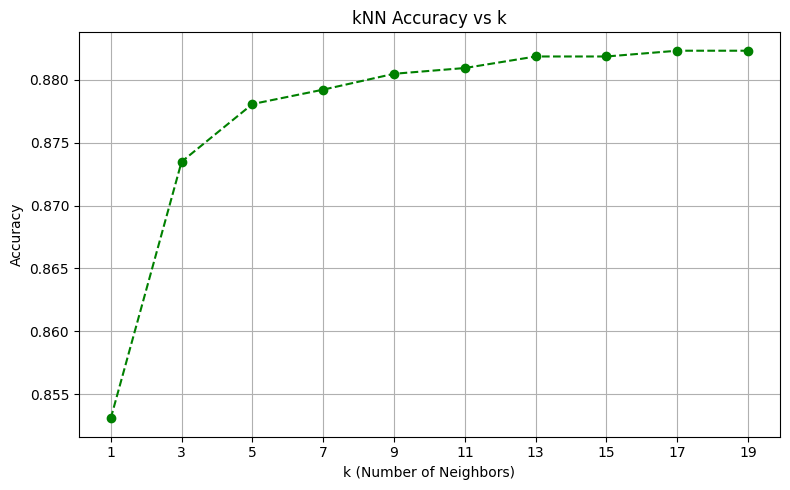

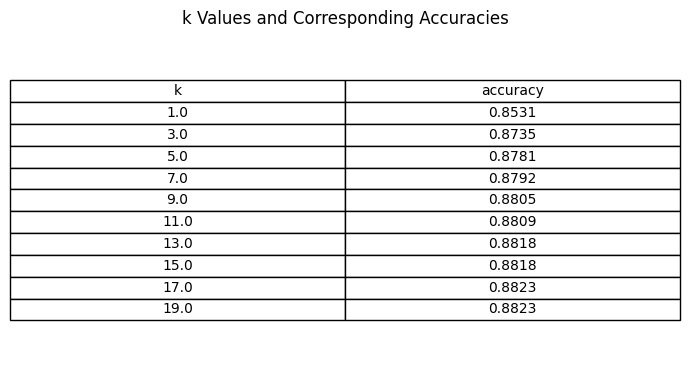

Selected best k based on test accuracy: 17


In [8]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Try 10 k values: 1, 3, ..., 19
k_values = list(range(1, 20, 2))
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    results.append({"k": k, "accuracy": accuracy_score(y_test, y_pred)})

results_df = pd.DataFrame(results)
display(results_df)

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o", linestyle="--", color="green")
plt.title("kNN Accuracy vs k")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(results_df["k"])
plt.grid(True)
plt.tight_layout()
plt.show()

# Display a figure-formatted table for the 10 k values
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.axis("off")
table_data = results_df.copy()
table_data["accuracy"] = table_data["accuracy"].round(4)
tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center",
 )
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)
plt.title("k Values and Corresponding Accuracies", pad=12)
plt.tight_layout()
plt.show()

best_k = int(results_df.loc[results_df["accuracy"].idxmax(), "k"] )
print(f"Selected best k based on test accuracy: {best_k}")

### Value: Evaluation and Protected Classes

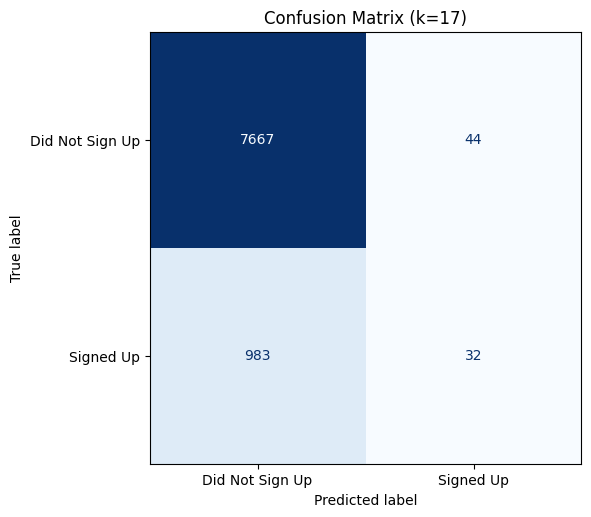

Classification Report:
              precision    recall  f1-score   support

           0     0.8864    0.9943    0.9372      7711
           1     0.4211    0.0315    0.0587      1015

    accuracy                         0.8823      8726
   macro avg     0.6537    0.5129    0.4979      8726
weighted avg     0.8322    0.8823    0.8350      8726



In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
final_predictions = final_knn.predict(X_test)

cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Sign Up", "Signed Up"],
 )

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title(f"Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, final_predictions, digits=4))

In [10]:
try:
    from fairlearn.metrics import (
        MetricFrame,
        demographic_parity_ratio,
        equalized_odds_ratio,
        false_negative_rate,
        false_positive_rate,
        selection_rate,
    )
except ModuleNotFoundError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "fairlearn"])
    from fairlearn.metrics import (
        MetricFrame,
        demographic_parity_ratio,
        equalized_odds_ratio,
        false_negative_rate,
        false_positive_rate,
        selection_rate,
    )

protected_columns = [
    col_lookup[c] for c in ["gender", "race"] if c in col_lookup
]
if not protected_columns:
    print("No protected class columns (Gender/Race) found in dataset.")
else:
    for col in protected_columns:
        sensitive = df.loc[X_test.index, col].astype(str)

        dpr = demographic_parity_ratio(
            y_true=y_test, y_pred=final_predictions, sensitive_features=sensitive
        )
        eor = equalized_odds_ratio(
            y_true=y_test, y_pred=final_predictions, sensitive_features=sensitive
        )

        metric_frame = MetricFrame(
            metrics={
                "selection_rate": selection_rate,
                "false_positive_rate": false_positive_rate,
                "false_negative_rate": false_negative_rate,
            },
            y_true=y_test,
            y_pred=final_predictions,
            sensitive_features=sensitive,
        )

        print("\n--- Fairness Metrics ---")
        print(f"Protected Class: {col}")
        print(f"Demographic Parity Ratio: {dpr:.4f}")
        print(f"Equalized Odds Ratio: {eor:.4f}")
        print("By-group metrics:")
        display(metric_frame.by_group)


--- Fairness Metrics ---
Protected Class: gender
Demographic Parity Ratio: 0.8751
Equalized Odds Ratio: 0.7566
By-group metrics:


,selection_rate,false_positive_rate,false_negative_rate
gender,,,
f,0.008123,0.005749,0.973029
m,0.009282,0.005664,0.964353



--- Fairness Metrics ---
Protected Class: race
Demographic Parity Ratio: 0.5846
Equalized Odds Ratio: 0.3982
By-group metrics:


,selection_rate,false_positive_rate,false_negative_rate
race,,,
asian,0.006732,0.003553,0.968992
black,0.009333,0.006356,0.968627
hispanic,0.011515,0.008924,0.969925
white,0.007326,0.004107,0.966102
